In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
data = load_breast_cancer()
df = load_breast_cancer(as_frame=True).frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X = df.drop(columns=['target']) # Features. Variables independientes
y = pd.Categorical.from_codes(data.target, data.target_names) # Target. Variable dependiente

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Clasificador Random Forest (Ejemplo de Bagging de árboles de decisión)

In [5]:
RFC = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
RFC.fit(X_train, y_train)
y_pred_rfc = RFC.predict(X_test)
print("Accuracy Random Forest Classifier:", f"{accuracy_score(y_test, y_pred_rfc)*100:.2f}%")

Accuracy Random Forest Classifier: 97.37%


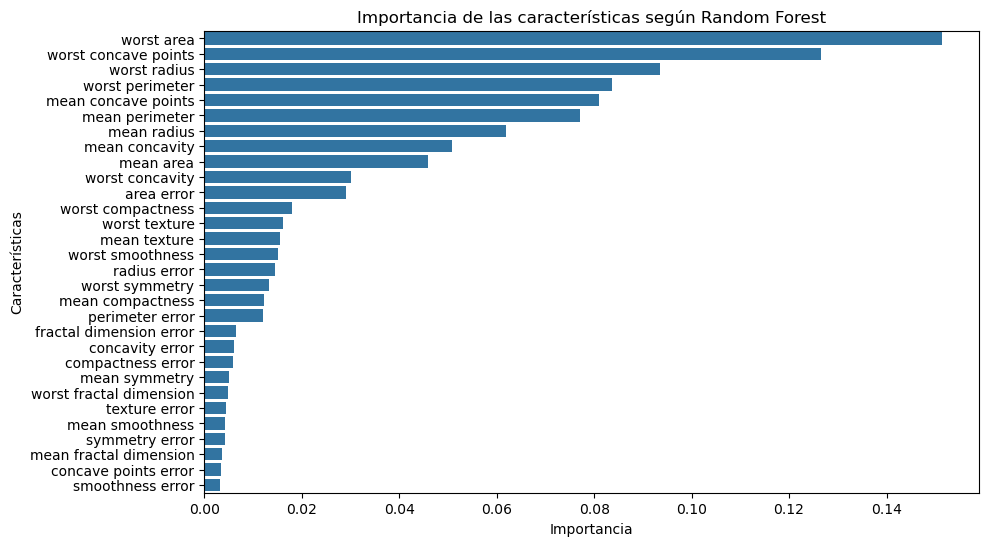

In [6]:
importancia_caracteristicas = pd.DataFrame(RFC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

## BOOSTING

### AdaBoost

In [8]:
from sklearn.tree import DecisionTreeClassifier
ABC = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=10), n_estimators=100, random_state=42) # Usamos un árbol de decisión como estimador base, con una profundidad máxima de 10, y 100 estimadores
ABC.fit(X_train, y_train) # Entrenamos el modelo
y_pred_abc = ABC.predict(X_test) # Hacemos predicciones
print("Accuracy AdaBoost Classifier:", f"{accuracy_score(y_test, y_pred_abc)*100:.2f}%")

Accuracy AdaBoost Classifier: 90.35%


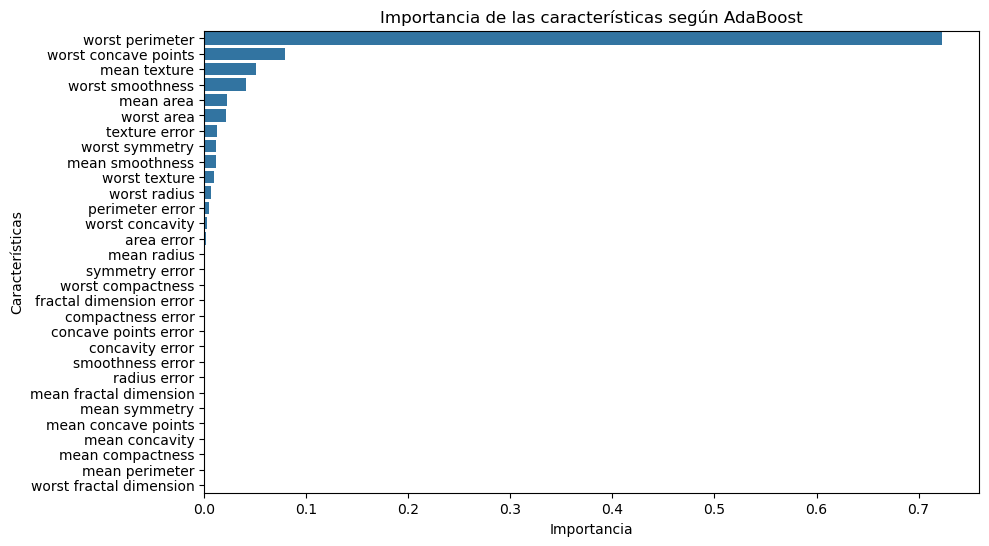

In [9]:
importancia_caracteristicas = pd.DataFrame(ABC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según AdaBoost')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

## Clasificador Gradient Boosting

In [17]:
GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=1, max_depth=10, random_state=42)
GBC.fit(X_train, y_train)
y_pred_gbc = GBC.predict(X_test)
print("Accuracy Gradient Boosting Classifier:", f"{accuracy_score(y_test, y_pred_gbc)*100:.2f}%")

Accuracy Gradient Boosting Classifier: 93.86%


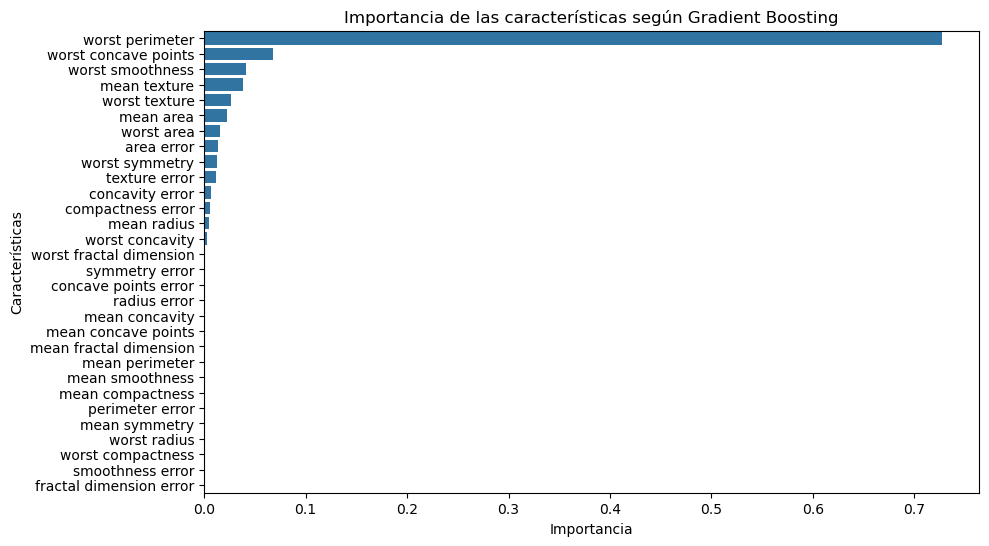

In [18]:
importancia_caracteristicas = pd.DataFrame(GBC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según Gradient Boosting')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

### XGBOOST

In [25]:
y_numerica = 1 - df['target'] # Invertimos las clases para que 1 sea maligno y 0 benigno (los malignos son los positivos, los benignos los negativos)
 

In [26]:
print(y_numerica.value_counts())

target
0    357
1    212
Name: count, dtype: int64


In [31]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y_numerica, test_size=0.2, random_state=42, stratify=y_numerica)
XGBC = XGBClassifier(n_estimators=100, learning_rate=1, max_depth=10, eval_metric='logloss', random_state=42) # eval_metric puede ser 'logloss' para clasificación binaria o 'mlogloss' para clasificación multiclase
XGBC.fit(X_train_xgb, y_train_xgb) # Entrenamos el modelo
y_pred_xgb = XGBC.predict(X_test_xgb) # Hacemos predicciones
print("Accuracy XGBoost Classifier:", f"{accuracy_score(y_test_xgb, y_pred_xgb)*100:.2f}%")


Accuracy XGBoost Classifier: 96.49%


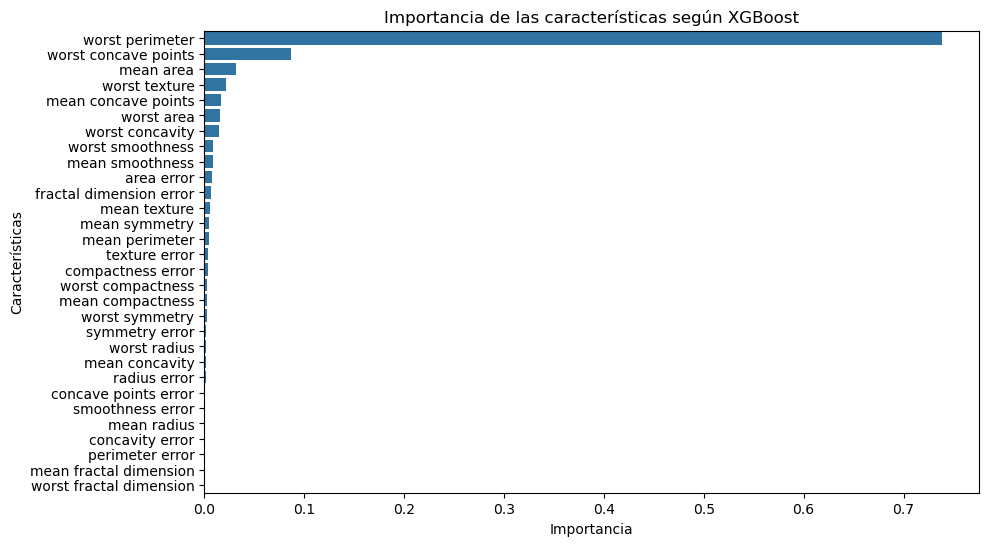

In [32]:
importancia_caracteristicas = pd.DataFrame(XGBC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según XGBoost')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

### CatBoost

In [33]:
from catboost import CatBoostClassifier

CBC = CatBoostClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42, verbose=0) # verbose=0 para evitar mostrar el progreso del entrenamiento
CBC.fit(X_train_xgb, y_train_xgb) # Entrenamos el modelo (usamos los mismos datos que XGBoost)
y_pred_cbc = CBC.predict(X_test_xgb) # Hacemos predicciones
print("Accuracy CatBoost Classifier:", f"{accuracy_score(y_test_xgb, y_pred_cbc)*100:.2f}%")

Accuracy CatBoost Classifier: 96.49%


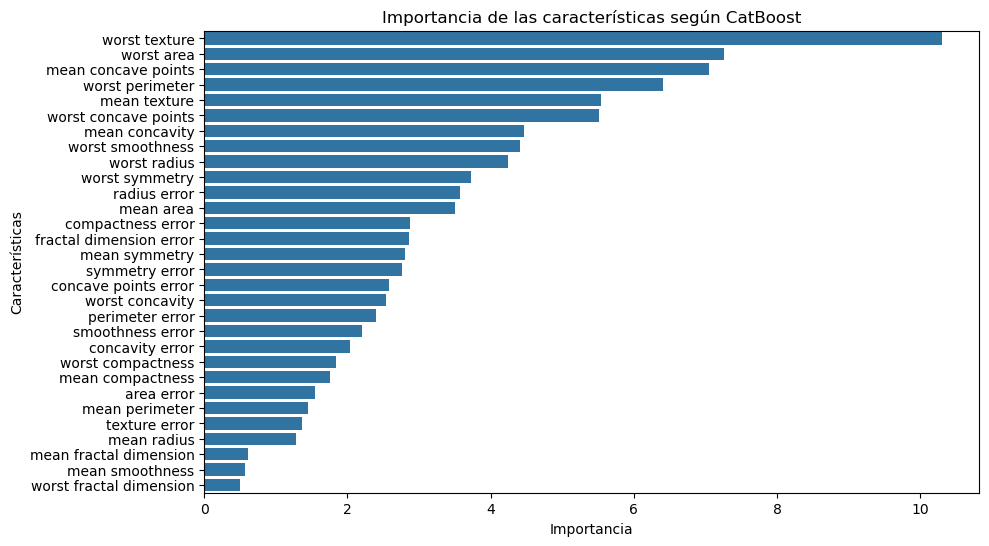

In [34]:
importancia_caracteristicas = pd.DataFrame(CBC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según CatBoost')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

### LightGBM

In [35]:
from lightgbm import LGBMClassifier

LGBMC = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42, verbose=-1) # verbose=-1 para evitar mostrar mensajes durante el entrenamiento
LGBMC.fit(X_train_xgb, y_train_xgb) # Entrenamos el modelo (usamos los mismos datos que XGBoost)
y_pred_lgbm = LGBMC.predict(X_test_xgb) # Hacemos predicciones
print("Accuracy LightGBM Classifier:", f"{accuracy_score(y_test_xgb, y_pred_lgbm)*100:.2f}%")

Accuracy LightGBM Classifier: 96.49%


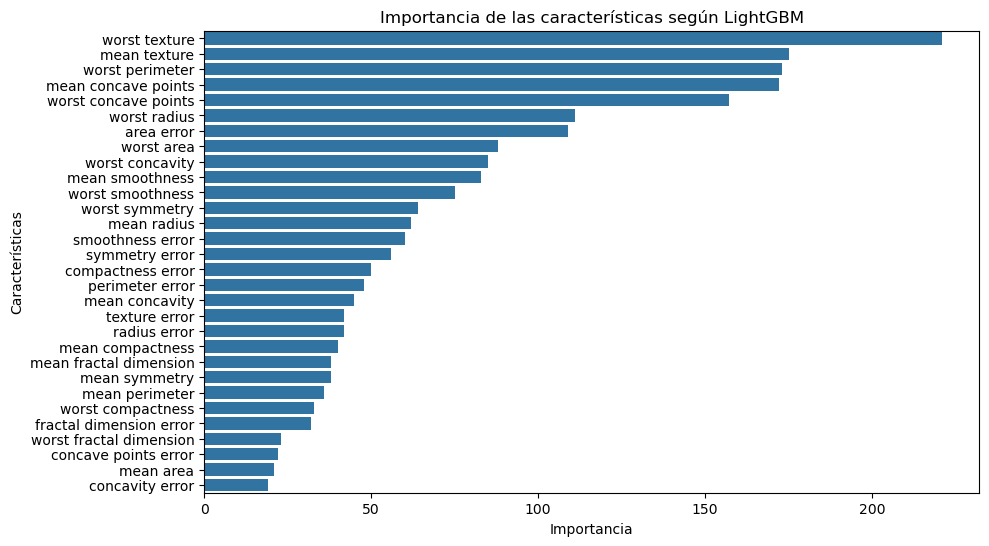

In [36]:
importancia_caracteristicas = pd.DataFrame(LGBMC.feature_importances_, index=X.columns, columns=['Importancia']).sort_values(by='Importancia', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importancia_caracteristicas.Importancia, y=importancia_caracteristicas.index)
plt.title('Importancia de las características según LightGBM')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()